# Customer Purchase Prediction

## Objective
Predict whether a customer will make a purchase based on demographic and behavioral data to improve marketing efficiency.

## Business Understanding

- Predict customer purchase behavior (Yes/No)
- Reduce marketing costs by targeting high-intent users
- Improve conversion rates
- Used by marketing and CRM teams

In [52]:
import pandas as pd
import numpy as np

df=pd.read_csv("customer_purchase_data.csv")
df

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1
...,...,...,...,...,...,...,...,...,...
1495,39,1,65048.141834,13,0,34.590743,0,5,1
1496,67,1,28775.331069,18,2,17.625707,0,1,1
1497,40,1,57363.247541,7,4,12.206033,0,0,0
1498,63,0,134021.775532,16,2,37.311634,1,0,1


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


## Data Preprocessing

- Handling missing values
- Feature scaling

In [54]:
print(df.isnull().sum())

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("PurchaseStatus", axis=1)

X_scaled = scaler.fit_transform(X)

# Convert back to dataframe
X = pd.DataFrame(X_scaled, columns=X.columns)
y = df["PurchaseStatus"]

## Exploratory Data Analysis

Understanding customer behavior patterns.

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

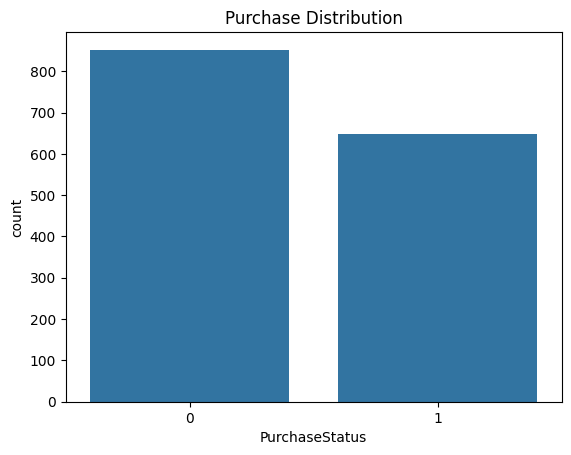

In [59]:
#purchase distribution count plot
sns.countplot(x='PurchaseStatus', data=df)
plt.title("Purchase Distribution")
plt.show()

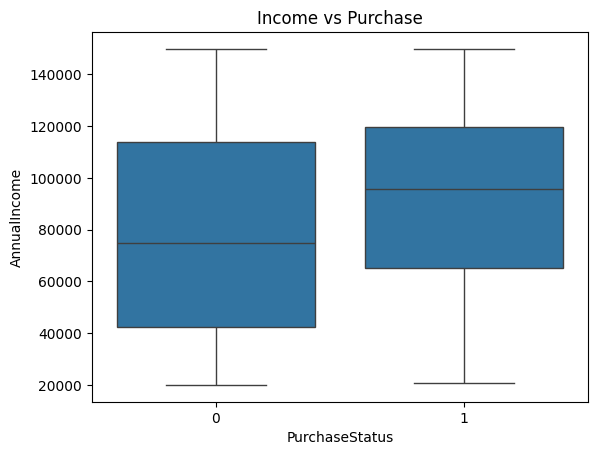

In [60]:
#income vs purchase box blot
sns.boxplot(x='PurchaseStatus', y='AnnualIncome', data=df)
plt.title("Income vs Purchase")
plt.show()

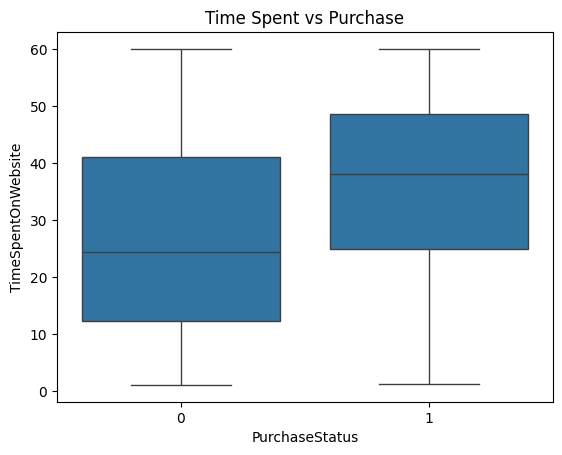

In [61]:
sns.boxplot(x='PurchaseStatus', y='TimeSpentOnWebsite', data=df)
plt.title("Time Spent vs Purchase")
plt.show()

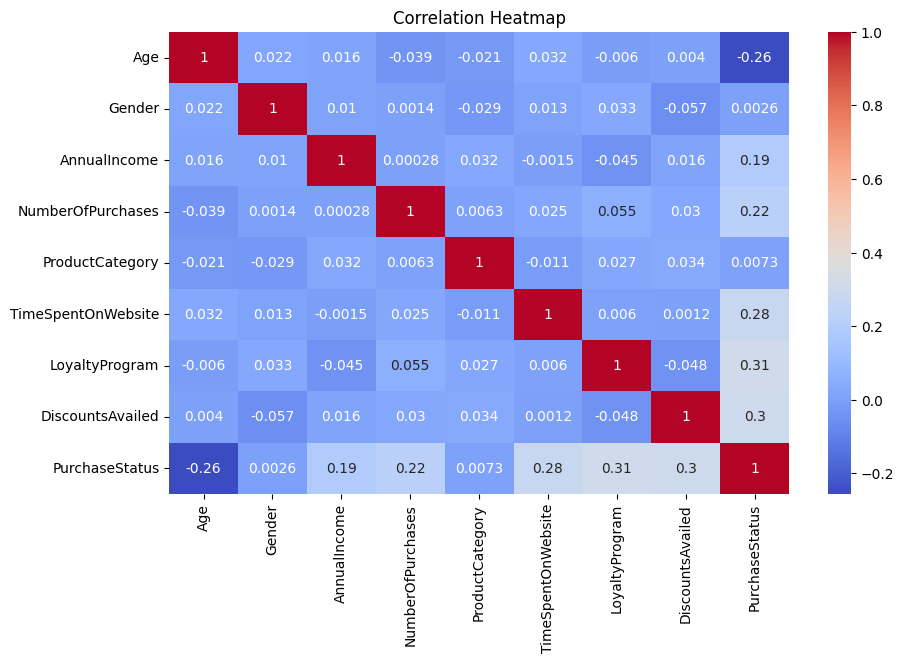

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

Creating new features to improve model performance.

In [63]:
df["Engagement_Score"] = df["TimeSpentOnWebsite"] + df["DiscountsAvailed"]
df["Loyalty_Engagement"] = df["LoyaltyProgram"] * df["TimeSpentOnWebsite"]

In [64]:
df["Purchase_Frequency_Level"] = pd.cut(df["NumberOfPurchases"],bins=3,labels=["Low", "Medium", "High"])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Purchase_Frequency_Level"] = le.fit_transform(df["Purchase_Frequency_Level"])

In [38]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus,Engagement_Score,Loyalty_Engagement,Purchase_Frequency_Level
0,40,1,66120.267939,8,0,30.568601,0,5,1,35.568601,0.000000,2
1,20,1,23579.773583,4,2,38.240097,0,5,0,43.240097,0.000000,1
2,27,1,127821.306432,11,2,31.633212,1,0,1,31.633212,31.633212,2
3,24,1,137798.623120,19,3,46.167059,0,4,1,50.167059,0.000000,0
4,31,1,99300.964220,19,1,19.823592,0,0,1,19.823592,0.000000,0


## Train-Test Split

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

PurchaseStatus
1    682
0    682
Name: count, dtype: int64


## Model Building

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [72]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [73]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [74]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [76]:
def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("AUC:", auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    return acc, prec, rec, f1, auc

In [77]:
lr_metrics = evaluate_model(lr)


Accuracy: 0.83
Precision: 0.7925925925925926
Recall: 0.823076923076923
F1 Score: 0.8075471698113208
AUC: 0.8986877828054299
Confusion Matrix:
 [[142  28]
 [ 23 107]]


In [78]:
dt_metrics = evaluate_model(dt)


Accuracy: 0.8733333333333333
Precision: 0.8432835820895522
Recall: 0.8692307692307693
F1 Score: 0.8560606060606061
AUC: 0.8728506787330317
Confusion Matrix:
 [[149  21]
 [ 17 113]]


In [79]:
rf_metrics = evaluate_model(rf)

Accuracy: 0.9266666666666666
Precision: 0.9285714285714286
Recall: 0.9
F1 Score: 0.9140625
AUC: 0.9378280542986427
Confusion Matrix:
 [[161   9]
 [ 13 117]]


## Model Comparison

In [80]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_metrics[0], dt_metrics[0], rf_metrics[0]],
    "Precision": [lr_metrics[1], dt_metrics[1], rf_metrics[1]],
    "Recall": [lr_metrics[2], dt_metrics[2], rf_metrics[2]],
    "F1 Score": [lr_metrics[3], dt_metrics[3], rf_metrics[3]],
    "AUC": [lr_metrics[4], dt_metrics[4], rf_metrics[4]]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Logistic Regression  0.830000   0.792593  0.823077  0.807547  0.898688
1        Decision Tree  0.873333   0.843284  0.869231  0.856061  0.872851
2        Random Forest  0.926667   0.928571  0.900000  0.914062  0.937828


In [81]:
comparison.to_csv("model_comparison.csv", index=False)

## Feature Importance

In [82]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

              Feature  Importance
5  TimeSpentOnWebsite    0.209026
0                 Age    0.175501
7    DiscountsAvailed    0.163697
2        AnnualIncome    0.148854
3   NumberOfPurchases    0.142667
6      LoyaltyProgram    0.107362
4     ProductCategory    0.037614
1              Gender    0.015279


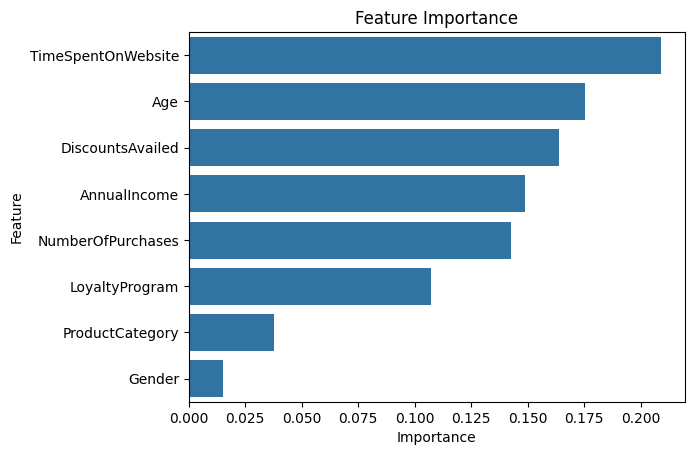

In [83]:
sns.barplot(x="Importance", y="Feature", data=feature_importance)

plt.title("Feature Importance")
plt.savefig("visual outputs/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

## Business Recommendations

- Target high-income customers
- Focus on high-engagement users
- Prioritize loyal customers

## Conclusion

Random Forest performed best and can be used to improve marketing targeting and conversion rates.